<a href="https://colab.research.google.com/github/brigithsuarez-oss/TALLER-1/blob/main/TALLER%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
pip install ucimlrepo

Ejecutar el código para extraer la base de datos

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

### Resumen del Dataset 'Online Retail'

Este conjunto de datos contiene todas las transacciones ocurridas entre el 01/12/2010 y el 09/12/2011 para un minorista en línea no comercial con sede y registro en el Reino Unido. La empresa vende principalmente regalos únicos para toda ocasión. Muchos de sus clientes son mayoristas.

*   **ID de UCI**: 352
*   **Nombre**: Online Retail
*   **Tipo de Datos**: Transaccional, multivariado, secuencial, serie de tiempo.
*   **Área**: Negocios
*   **Tareas Potenciales**: Clasificación, Agrupamiento (Clustering).
*   **Número de Instancias**: 541,909 transacciones.
*   **Número de Características**: 6 (excluyendo las columnas de ID).
*   **Valores Faltantes**: El dataset indica que no tiene valores faltantes en las características principales, aunque en la práctica, a veces los IDs de cliente pueden estar ausentes, lo cual se puede verificar durante el preprocesamiento.
*   **Fecha de Creación del Dataset**: 2015

### Variables del Dataset:

A continuación, se detallan las variables presentes en este conjunto de datos:

*   **`InvoiceNo` (Número de Factura)**: Un número integral de 6 dígitos asignado de forma única a cada transacción. Si este código comienza con la letra 'c', indica una cancelación.
*   **`StockCode` (Código de Producto)**: Un número integral de 5 dígitos asignado de forma única a cada producto distinto.
*   **`Description` (Descripción)**: El nombre del producto (artículo).
*   **`Quantity` (Cantidad)**: Las cantidades de cada producto (artículo) por transacción. Es un valor numérico.
*   **`InvoiceDate` (Fecha de Factura)**: La fecha y hora en que se generó cada transacción.
*   **`UnitPrice` (Precio Unitario)**: El precio del producto por unidad en libras esterlinas. Es un valor numérico continuo.
*   **`CustomerID` (ID de Cliente)**: Un número integral de 5 dígitos asignado de forma única a cada cliente.
*   **`Country` (País)**: El nombre del país donde reside cada cliente.

### ¿Qué puedo hacer con esta base de datos?

Este dataset es excelente para una variedad de análisis relacionados con el comercio electrónico y el comportamiento del cliente:

1.  **Análisis RFM (Recencia, Frecuencia, Valor Monetario)**: Puedes segmentar a los clientes basándote en cuándo fue su última compra (Recencia), con qué frecuencia compran (Frecuencia) y cuánto gastan (Valor Monetario).
2.  **Segmentación de Clientes**: Identificar diferentes grupos de clientes con base en sus patrones de compra.
3.  **Análisis de Cestas de Compra (Market Basket Analysis)**: Descubrir qué productos tienden a comprarse juntos (reglas de asociación).
4.  **Predicción de Ventas**: Analizar tendencias de ventas a lo largo del tiempo y predecir ventas futuras.
5.  **Detección de Fraudes**: Las transacciones canceladas ('InvoiceNo' que comienzan con 'c') o con cantidades negativas pueden ser indicativos de devoluciones o posibles actividades fraudulentas.
6.  **Análisis Geográfico**: Ver de qué países provienen la mayoría de las ventas o clientes.
7.  **Optimización de Inventario**: Entender la popularidad de los productos para gestionar mejor el inventario.
8.  **Recomendación de Productos**: Basarse en el historial de compras de un cliente para sugerirle nuevos productos.

Para empezar a explorar, podríamos limpiar los datos, manejar posibles valores atípicos, convertir las fechas al formato correcto y luego comenzar con algunos análisis descriptivos.

1.  Se crea el script para poder leer los datos que existen en la base de datos

In [5]:
import pandas as pd
from ucimlrepo import fetch_ucirepo # Asegurarse de que online_retail esté disponible

# fetch dataset again to ensure online_retail is defined
online_retail = fetch_ucirepo(id=352)

data_url = online_retail.metadata['data_url'] # Corrected: Get the URL from the metadata dictionary
df_raw = pd.read_csv(data_url)

print("Primeras 5 filas del DataFrame directamente del archivo CSV:")
display(df_raw.head())

Primeras 5 filas del DataFrame directamente del archivo CSV:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Ahora tienes los datos completos en un DataFrame llamado `df_raw`. La variable `X` que se cargó inicialmente solo contenía las características, mientras que `df_raw` contendrá todas las columnas del archivo original, incluyendo `InvoiceNo`, `StockCode`, etc., tal como se describen en las variables.

2. Limpieza de datos

### 2.1. Inspección Inicial del DataFrame

Primero, vamos a obtener un resumen del DataFrame, incluyendo el tipo de datos de cada columna y la cantidad de valores no nulos. Esto nos ayudará a identificar columnas con valores faltantes (`NaN`) y aquellas que necesiten una conversión de tipo de dato.

In [7]:
# Mostrar información del DataFrame: tipos de datos y valores no nulos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


El resultado de `df_raw.info()` nos muestra que:

*   `Description` tiene 1454 valores faltantes (541909 - 540455).
*   `CustomerID` tiene 135080 valores faltantes (541909 - 406829). Esta es una cantidad significativa.
*   `InvoiceDate` es de tipo `object`, lo que significa que es una cadena de texto y debe convertirse a formato `datetime` para poder realizar análisis temporales.
*   `Quantity` y `UnitPrice` son numéricos (`int64` y `float64` respectivamente), lo cual es correcto.

### 2.2. Manejo de Valores Faltantes

Analicemos las columnas con valores faltantes:

1.  **`Description`**: La descripción del producto es importante para entender qué se está vendiendo. Los registros sin descripción pueden ser problemáticos. Para este análisis, dado que la cantidad de valores faltantes es relativamente pequeña (menos del 1% del total), optaremos por eliminar las filas donde la `Description` sea nula.
2.  **`CustomerID`**: La columna `CustomerID` tiene una gran cantidad de valores faltantes. Si nuestro objetivo principal fuera un análisis centrado en el cliente (como el análisis RFM), tendríamos que decidir si estas transacciones sin ID de cliente son útiles o si deben ser eliminadas. Para un análisis general de ventas, podríamos considerar retenerlas o eliminarlas. Dado que muchas de las tareas posibles mencionadas (RFM, Segmentación de Clientes) se basan en `CustomerID`, **eliminaremos las filas donde `CustomerID` sea nulo** para asegurar la integridad en futuros análisis centrados en el cliente.

In [10]:
# Eliminar filas con valores nulos en 'Description' y 'CustomerID'
df_cleaned = df_raw.dropna(subset=['Description', 'CustomerID']).copy()

print(f"Filas antes de eliminar nulos: {len(df_raw)}")
print(f"Filas después de eliminar nulos: {len(df_cleaned)}")

# Verificar si aún hay valores nulos en estas columnas
print("\nValores nulos después de la eliminación:")
print(df_cleaned[['Description', 'CustomerID']].isnull().sum())

Filas antes de eliminar nulos: 541909
Filas después de eliminar nulos: 406829

Valores nulos después de la eliminación:
Description    0
CustomerID     0
dtype: int64


### 2.3. Conversión de Tipos de Datos

Ahora, convertiremos la columna `InvoiceDate` a un formato de fecha y hora (`datetime`) para poder trabajar con ella de forma eficiente (por ejemplo, extraer el año, mes, día, hora, o calcular duraciones).

In [9]:
# Convertir 'InvoiceDate' a formato datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Verificar los tipos de datos después de la conversión
print("Tipos de datos después de convertir InvoiceDate:")
print(df_cleaned.info())

Tipos de datos después de convertir InvoiceDate:
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB
None


/tmp/ipykernel_849/1999298179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])


### 2.4. Manejo de Valores Inválidos en `Quantity` y `UnitPrice`

Las columnas `Quantity` (Cantidad) y `UnitPrice` (Precio Unitario) son fundamentales para cualquier análisis de ventas. Es importante que contengan valores lógicos y positivos.

*   **`Quantity`**: Una cantidad no puede ser cero o negativa para una compra válida. Las cantidades negativas en este dataset a menudo indican devoluciones (cuyos `InvoiceNo` pueden empezar con 'c'). Sin embargo, para un análisis de ventas y valor monetario positivo, nos enfocaremos en transacciones con `Quantity` positiva. Por lo tanto, eliminaremos las filas donde `Quantity` sea menor o igual a cero.
*   **`UnitPrice`**: Un precio unitario tampoco puede ser cero o negativo. Un precio unitario de cero no tiene sentido en el contexto de una venta. Eliminaremos las filas donde `UnitPrice` sea menor o igual a cero.

In [11]:
# Eliminar filas donde Quantity <= 0
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]

# Eliminar filas donde UnitPrice <= 0
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]

print(f"Filas después de filtrar cantidades y precios inválidos: {len(df_cleaned)}")

# Verificar si aún existen valores inválidos
print("\nCantidad de valores <= 0 en Quantity:", df_cleaned[df_cleaned['Quantity'] <= 0].shape[0])
print("Cantidad de valores <= 0 en UnitPrice:", df_cleaned[df_cleaned['UnitPrice'] <= 0].shape[0])

Filas después de filtrar cantidades y precios inválidos: 397884

Cantidad de valores <= 0 en Quantity: 0
Cantidad de valores <= 0 en UnitPrice: 0


### 2.5. Creación de Nuevas Características Derivadas

Para facilitar futuros análisis, es útil crear nuevas columnas a partir de las existentes:

*   **`TotalPrice`**: El valor total de cada transacción de línea, calculado como `Quantity * UnitPrice`.
*   **`Hour`**: La hora del día de la `InvoiceDate`.
*   **`Month`**: El mes de la `InvoiceDate`.
*   **`Year`**: El año de la `InvoiceDate`.
*   **`DayOfWeek`**: El día de la semana de la `InvoiceDate` (Lunes=0, Domingo=6).

In [13]:
# Asegurar que InvoiceDate sea datetime antes de extraer las características temporales
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Calcular TotalPrice
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Extraer la hora, mes, año y día de la semana de InvoiceDate
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour
df_cleaned['Month'] = df_cleaned['InvoiceDate'].dt.month
df_cleaned['Year'] = df_cleaned['InvoiceDate'].dt.year
df_cleaned['DayOfWeek'] = df_cleaned['InvoiceDate'].dt.dayofweek # Lunes=0, Domingo=6

print("Primeras 5 filas del DataFrame con las nuevas columnas:")
display(df_cleaned.head())

Primeras 5 filas del DataFrame con las nuevas columnas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour,Month,Year,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,12,2010,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,12,2010,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2


ANALISIS DESCRIPTIVO

In [23]:
import sqlite3
import pandas as pd

In [25]:
# ============================================
# 2. CREAR BASE DE DATOS SQLITE
# ============================================

database = "retail_cleaned.db"

conn = sqlite3.connect(database)


# ============================================
# 3. GUARDAR LOS DATOS LIMPIOS
# ============================================

df_cleaned.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("\nDatos guardados correctamente en SQLite.")
print(f"Base de datos: {database}")
print("Tabla: sales")
print(f"Número de registros: {len(df_cleaned)}")


# ============================================
# 4. COMPROBAR QUE SE GUARDARON
# ============================================

query = """
SELECT *
FROM sales
LIMIT 5;
"""

df_sql = pd.read_sql_query(query, conn)

print("\nPrimeros 5 registros desde SQLite:")
display(df_sql)


# ============================================
# 5. CERRAR CONEXIÓN
# ============================================

conn.close()


Datos guardados correctamente en SQLite.
Base de datos: retail_cleaned.db
Tabla: sales
Número de registros: 397884

Primeros 5 registros desde SQLite:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour,Month,Year,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,12,2010,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,12,2010,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12,2010,2


### 3. Análisis Descriptivo de los Datos Limpios

Después de la limpieza, el conjunto de datos `df_cleaned` está listo para ser explorado. Este análisis nos ayudará a entender las tendencias generales y posibles patrones.

#### 3.1. Estadísticas Descriptivas de Columnas Numéricas

Vamos a obtener un resumen estadístico de las columnas numéricas (`Quantity`, `UnitPrice`, `TotalPrice`). Esto nos dará una idea de la media, desviación estándar, valores mínimos y máximos, y los cuartiles.

In [14]:
# Estadísticas descriptivas de las columnas numéricas
display(df_cleaned[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

,Quantity,UnitPrice,TotalPrice
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


**Observaciones de las estadísticas descriptivas:**

*   **`Quantity`**: La cantidad promedio por transacción es de aproximadamente 13 unidades, con una desviación estándar considerable, lo que indica una alta variabilidad. El valor máximo es muy alto (80995), lo que sugiere algunas transacciones con grandes volúmenes.
*   **`UnitPrice`**: El precio unitario promedio es de alrededor de £3.12. También hay una alta variabilidad, y el valor máximo de £8142.75 indica productos de muy alto valor.
*   **`TotalPrice`**: El precio total promedio por línea de transacción es de aproximadamente £20. La distribución es similar a `Quantity` y `UnitPrice`, con un valor máximo extremadamente alto para una sola línea (más de £164,000), lo que podría ser un caso atípico o una transacción mayorista muy grande.

#### PREGUNTA 1  ¿Cual es el país con mayor distribución de productos?

Analizaremos la distribución de las transacciones por `Country`. Esto nos mostrará de dónde provienen la mayoría de nuestros clientes.

In [15]:
# Contar el número de transacciones por país
country_counts = df_cleaned['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'TransactionCount']

print("Top 10 países por número de transacciones:")
display(country_counts.head(10))

Top 10 países por número de transacciones:


,Country,TransactionCount
0,United Kingdom,354321
1,Germany,9040
2,France,8341
3,EIRE,7236
4,Spain,2484
5,Netherlands,2359
6,Belgium,2031
7,Switzerland,1841
8,Portugal,1462
9,Australia,1182


**Observaciones sobre la distribución de países:**

*   El **Reino Unido** domina abrumadoramente el número de transacciones, lo cual es esperado dado que la empresa tiene sede allí. Esto sugiere que cualquier análisis detallado podría necesitar considerar el Reino Unido por separado o enfocarse en las diferencias entre países no-Reino Unido.
*   Otros países europeos como **Alemania**, **Francia** y **EIRE** (Irlanda) también tienen una presencia significativa.

#### PREGUNTA 2. ¿Cuales son los productos más vendidos?

Veamos cuáles son los productos (`Description`) que generan más ventas, tanto en cantidad de ítems vendidos como en ingresos generados (`TotalPrice`).

In [16]:
# Top 10 productos por cantidad vendida
top_products_quantity = df_cleaned.groupby('Description')['Quantity'].sum().nlargest(10).reset_index()
print("Top 10 productos por Cantidad Vendida:")
display(top_products_quantity)

print("\n")

# Top 10 productos por ingresos generados
top_products_revenue = df_cleaned.groupby('Description')['TotalPrice'].sum().nlargest(10).reset_index()
print("Top 10 productos por Ingresos Generados:")
display(top_products_revenue)

Top 10 productos por Cantidad Vendida:


,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,JUMBO BAG RED RETROSPOT,46181
4,WHITE HANGING HEART T-LIGHT HOLDER,36725
5,ASSORTED COLOUR BIRD ORNAMENT,35362
6,PACK OF 72 RETROSPOT CAKE CASES,33693
7,POPCORN HOLDER,30931
8,RABBIT NIGHT LIGHT,27202
9,MINI PAINT SET VINTAGE,26076




Top 10 productos por Ingresos Generados:


,Description,TotalPrice
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


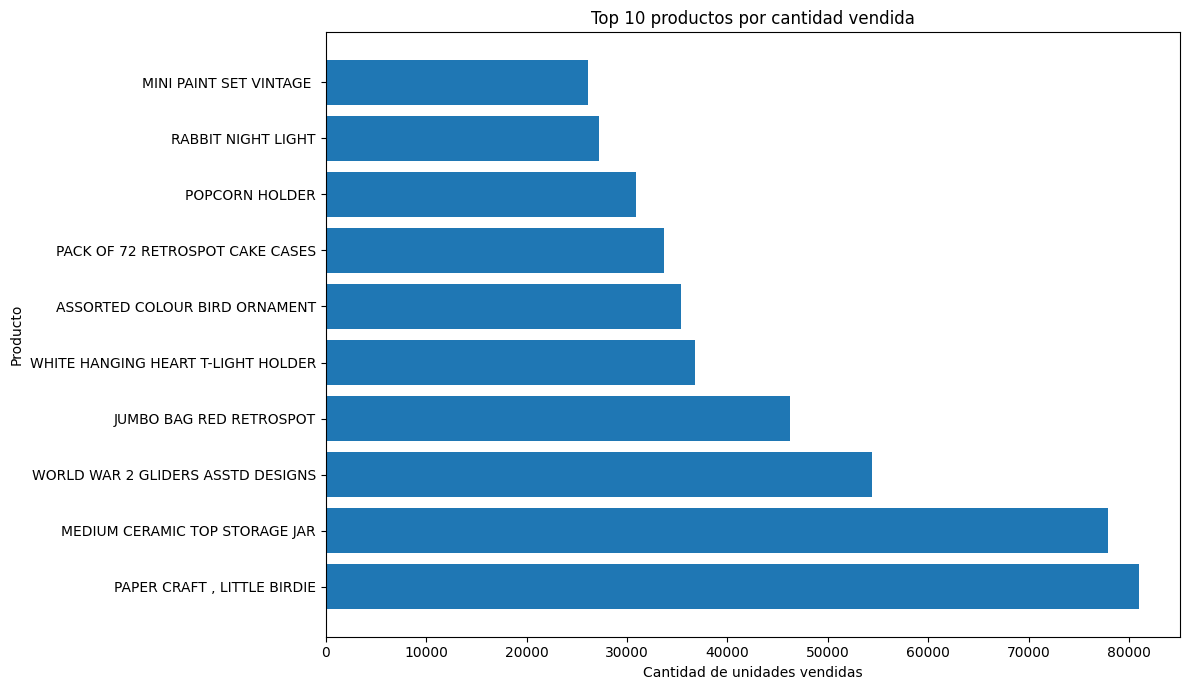

<Figure size 640x480 with 0 Axes>

In [45]:
import matplotlib.pyplot as plt

# ============================================
# TOP 10 PRODUCTOS POR CANTIDAD VENDIDA
# ============================================

plt.figure(figsize=(12, 7))

plt.barh(
    top_products_quantity['Description'],
    top_products_quantity['Quantity']
)

plt.title('Top 10 productos por cantidad vendida')
plt.xlabel('Cantidad de unidades vendidas')
plt.ylabel('Producto')

plt.tight_layout()
plt.show()

 #Guardar gráfico
plt.savefig(
    "visualizaciones/Top 10 de productos mas vendidos.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

**Observaciones sobre los productos más vendidos:**

*   Existe una lista de productos muy populares en términos de cantidad vendida y de ingresos. Items como 'PAPER CRAFT , LITTLE BIRDIE' y 'REGENCY CAKESTAND 3 TIER' son consistentemente populares.
*   Es interesante notar que los productos que se venden más en cantidad no siempre son los que generan más ingresos, lo que puede indicar diferentes márgenes o precios unitarios.

#### 3.4. Análisis Temporal

Exploremos las ventas a lo largo del tiempo, utilizando las columnas `Hour`, `Month` y `DayOfWeek`.

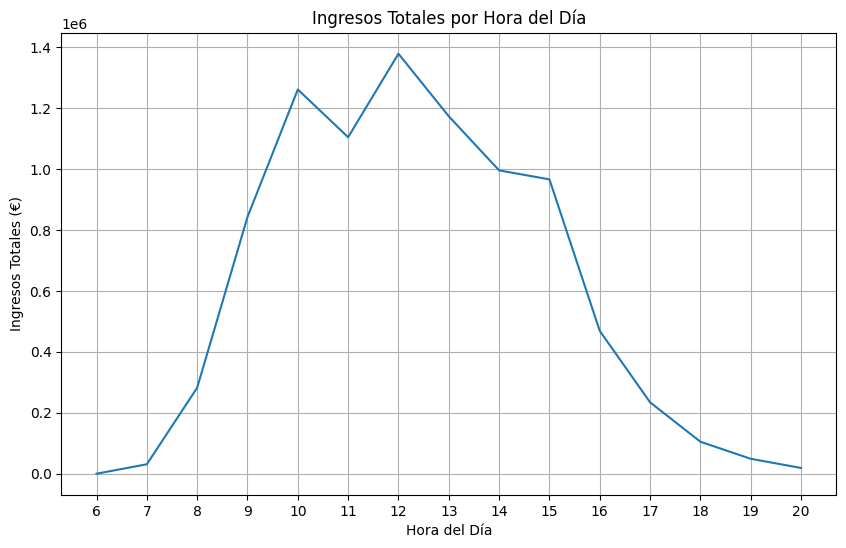

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_849/244298143.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeekName', y='TotalPrice', data=sales_by_dayofweek, palette='viridis')


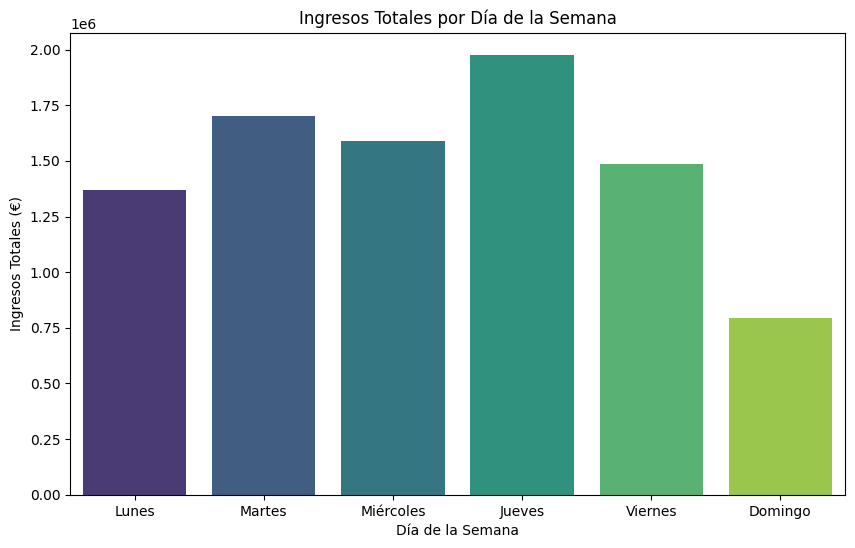

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_849/244298143.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='TotalPrice', data=sales_by_month, palette='magma')


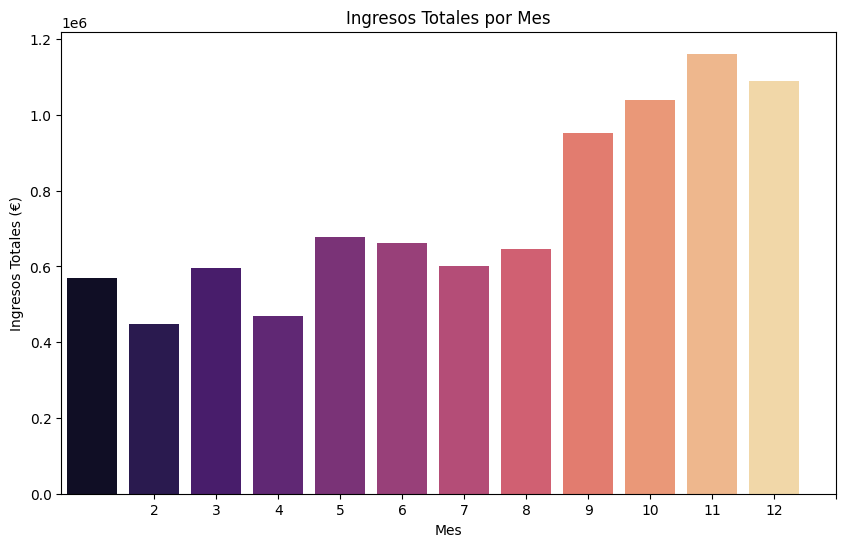

<Figure size 640x480 with 0 Axes>

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ventas por hora del día
sales_by_hour = df_cleaned.groupby('Hour')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Hour', y='TotalPrice', data=sales_by_hour)
plt.title('Ingresos Totales por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Ingresos Totales (€)')
plt.grid(True)
plt.xticks(range(6, 21)) # Asumiendo horario comercial
plt.show()

# Ventas por día de la semana
sales_by_dayofweek = df_cleaned.groupby('DayOfWeek')['TotalPrice'].sum().reset_index()
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
sales_by_dayofweek['DayOfWeekName'] = sales_by_dayofweek['DayOfWeek'].map(lambda x: day_names[x])


 #Guardar gráfico
plt.savefig(
    "visualizaciones/Ventas por dia.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeekName', y='TotalPrice', data=sales_by_dayofweek, palette='viridis')
plt.title('Ingresos Totales por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Ingresos Totales (€)')
plt.show()

 #Guardar gráfico
plt.savefig(
    "visualizaciones/Ventas por semana.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# Ventas por mes
sales_by_month = df_cleaned.groupby('Month')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='TotalPrice', data=sales_by_month, palette='magma')
plt.title('Ingresos Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos Totales (€)')
plt.xticks(range(1, 13))
plt.show()

 #Guardar gráfico
plt.savefig(
    "visualizaciones/Ventas por mes.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

**Observaciones del análisis temporal:**

*   **Por Hora**: Las ventas suelen concentrarse en las horas centrales del día, con un pico claro. Esto es típico de un comercio minorista en línea.
*   **Por Día de la Semana**: Las ventas muestran variaciones significativas a lo largo de la semana. Puede haber días específicos con mayor o menor actividad como se ve en el gráfico en este caso es el día jueves.
*   **Por Mes**: Las ventas pueden variar mucho a lo largo del año, posiblemente influenciadas por festividades, temporadas de compras o eventos especiales. Diciembre, por ejemplo, suele ser un mes de ventas muy altas, sin embargo aqui se puede ver que es en noviembre.



#### PREGUNTA 3

 ¿Qué producto es el más demandado en los países con mayor venta?

Vamos a identificar los países que generan la mayor cantidad de ingresos y, dentro de ellos, cuál es el producto más vendido.

In [18]:
# 1. Calcular los ingresos totales por país
total_sales_by_country = df_cleaned.groupby('Country')['TotalPrice'].sum().nlargest(5).reset_index()
print("Top 5 países por Ingresos Totales:")
display(total_sales_by_country)

# Obtener la lista de los países principales
top_countries = total_sales_by_country['Country'].tolist()

# 2. Filtrar el DataFrame para incluir solo los países principales
df_top_countries = df_cleaned[df_cleaned['Country'].isin(top_countries)]

# 3. Encontrar el producto más vendido (por cantidad) en estos países
top_product_in_top_countries_quantity = df_top_countries.groupby('Description')['Quantity'].sum().nlargest(1).reset_index()
print(f"\nProducto más vendido (por Cantidad) en los Top {len(top_countries)} países:")
display(top_product_in_top_countries_quantity)

# 4. Encontrar el producto que más ingresos genera en estos países
top_product_in_top_countries_revenue = df_top_countries.groupby('Description')['TotalPrice'].sum().nlargest(1).reset_index()
print(f"\nProducto que más Ingresos Genera en los Top {len(top_countries)} países:")
display(top_product_in_top_countries_revenue)



Top 5 países por Ingresos Totales:


,Country,TotalPrice
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050



Producto más vendido (por Cantidad) en los Top 5 países:


,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995



Producto que más Ingresos Genera en los Top 5 países:


,Description,TotalPrice
0,"PAPER CRAFT , LITTLE BIRDIE",168469.6


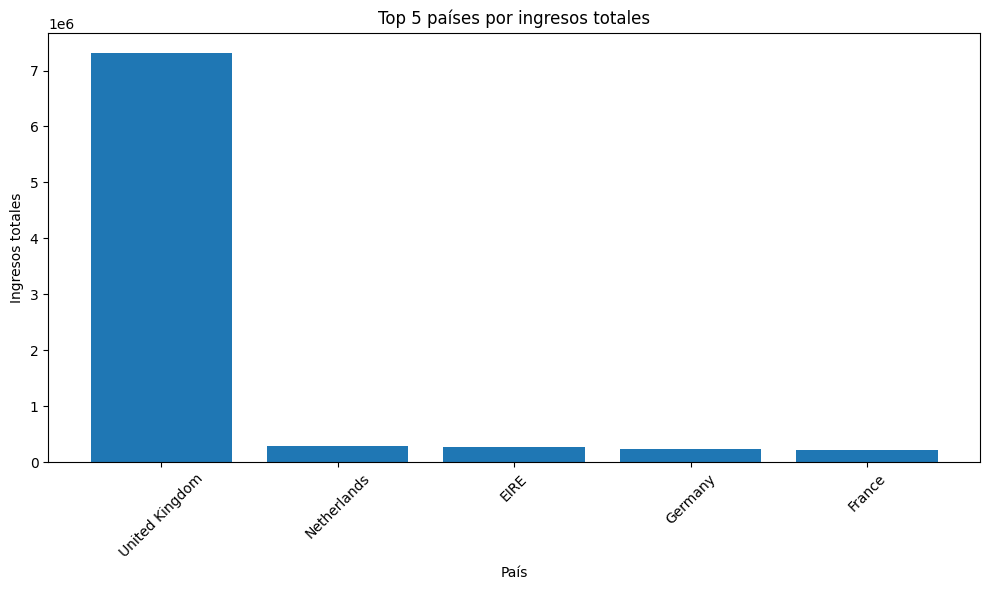

<Figure size 640x480 with 0 Axes>

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    total_sales_by_country['Country'],
    total_sales_by_country['TotalPrice']
)

plt.title('Top 5 países por ingresos totales')
plt.xlabel('País')
plt.ylabel('Ingresos totales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

 #Guardar gráfico
plt.savefig(
    "visualizaciones/5 paises por ingresos totales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PREGUNTA 4

¿Cuántos clientes del pais United Kingdom compran un producto que valga mas de 50?

In [31]:
uk_customers_over_50 = df_cleaned[
    (df_cleaned['Country'] == 'United Kingdom') &
    (df_cleaned['TotalPrice'] > 50)
]

# Contar clientes únicos
number_of_customers = uk_customers_over_50['CustomerID'].nunique()

print(
    f"Número de clientes de United Kingdom "
    f"que compraron productos por más de 50: {number_of_customers}"
)



Número de clientes de United Kingdom que compraron productos por más de 50: 1992


In [32]:
customer_purchases = (
    uk_customers_over_50[
        ['CustomerID', 'Description', 'Quantity',
         'UnitPrice', 'TotalPrice', 'InvoiceDate']
    ]
    .sort_values('TotalPrice', ascending=False)
)

display(customer_purchases)

,CustomerID,Description,Quantity,UnitPrice,TotalPrice,InvoiceDate
540421,16446.0,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,2011-12-09 09:15:00
61619,12346.0,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,2011-01-18 10:01:00
222680,15098.0,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,2011-06-10 15:28:00
173382,16029.0,POSTAGE,1,8142.75,8142.75,2011-05-03 13:46:00
348325,17450.0,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,2011-09-20 11:05:00
...,...,...,...,...,...,...
465766,16422.0,PACK OF 72 RETROSPOT CAKE CASES,120,0.42,50.40,2011-11-14 14:02:00
32203,17980.0,PAPER CHAIN KIT 50'S CHRISTMAS,17,2.95,50.15,2010-12-15 15:50:00
503573,15443.0,PAPER CHAIN KIT VINTAGE CHRISTMAS,17,2.95,50.15,2011-11-27 12:29:00
288349,16012.0,PINK REGENCY TEACUP AND SAUCER,17,2.95,50.15,2011-08-03 11:44:00


Productos comprados en United Kingdom con precio superior a 50:


,Description,Quantity
0,POSTAGE,2
1,DECORATIVE HANGING SHELVING UNIT,6
2,SCHOOL DESK AND CHAIR,8
3,REGENCY MIRROR WITH SHUTTERS,10
4,VINTAGE POST OFFICE CABINET,11
5,DOTCOM POSTAGE,13
6,Manual,20
7,CHEST NATURAL WOOD 20 DRAWERS,21
8,VINTAGE BLUE KITCHEN CABINET,23
9,RUSTIC SEVENTEEN DRAWER SIDEBOARD,30


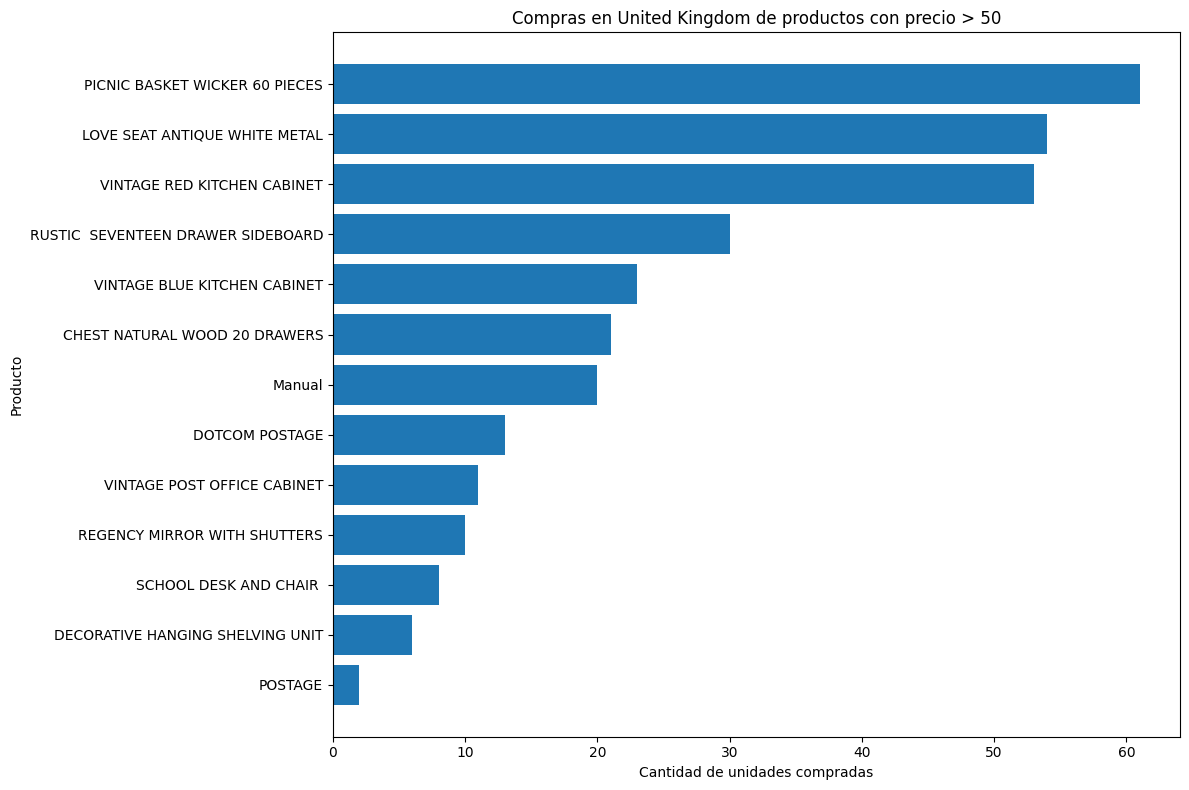

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

# ============================================
# 1. Filtrar las compras
# ============================================

uk_purchases_over_50 = df_cleaned[
    (df_cleaned['Country'] == 'United Kingdom') &
    (df_cleaned['UnitPrice'] > 50)
].copy()

# ============================================
# 2. Agrupar por producto y sumar cantidades
# ============================================

products_purchased = (
    uk_purchases_over_50
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=True)
)

# ============================================
# 3. Mostrar información
# ============================================

print("Productos comprados en United Kingdom con precio superior a 50:")
display(products_purchased.reset_index())

# ============================================
# 4. Crear gráfico
# ============================================

plt.figure(figsize=(12, 8))

plt.barh(
    products_purchased.index,
    products_purchased.values
)

plt.title(
    'Compras en United Kingdom de productos con precio > 50'
)

plt.xlabel('Cantidad de unidades compradas')
plt.ylabel('Producto')

plt.tight_layout()
plt.show()

 #Guardar gráfico
plt.savefig(
    "visualizaciones/Compras mayores a 50.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

METADATA

In [36]:
metadata = {
    'Número de registros': len(df_cleaned),
    'Número de columnas': len(df_cleaned.columns),
    'Clientes únicos': df_cleaned['CustomerID'].nunique(),
    'Productos únicos': df_cleaned['StockCode'].nunique(),
    'Países': df_cleaned['Country'].nunique(),
    'Facturas únicas': df_cleaned['InvoiceNo'].nunique(),
    'Ingresos totales': df_cleaned['TotalPrice'].sum(),
    'Precio promedio': df_cleaned['UnitPrice'].mean(),
    'Cantidad total vendida': df_cleaned['Quantity'].sum()
}

display(pd.DataFrame(
    metadata.items(),
    columns=['Metadata', 'Valor']
))

,Metadata,Valor
0,Número de registros,3.978840e+05
1,Número de columnas,1.300000e+01
2,Clientes únicos,4.338000e+03
3,Productos únicos,3.665000e+03
4,Países,3.700000e+01
5,Facturas únicas,1.853200e+04
6,Ingresos totales,8.911408e+06
7,Precio promedio,3.116488e+00
8,Cantidad total vendida,5.167812e+06


In [37]:
print("Primera fecha:", df_cleaned['InvoiceDate'].min())
print("Última fecha:", df_cleaned['InvoiceDate'].max())
print("Hora con mayor actividad:",
      df_cleaned['Hour'].mode()[0])
print("Mes con mayor cantidad de registros:",
      df_cleaned['Month'].mode()[0])

Primera fecha: 2010-12-01 08:26:00
Última fecha: 2011-12-09 12:50:00
Hora con mayor actividad: 12
Mes con mayor cantidad de registros: 11


In [38]:
import os
import matplotlib.pyplot as plt

# Crear carpeta para guardar las visualizaciones
os.makedirs("visualizaciones", exist_ok=True)

In [46]:
import os

print(os.getcwd())

/content
